In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, model_inference
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-21 16:08:02,877	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Load Data

In [2]:
rat_names = ['achilles', 'gatsby','cicero', 'buddy']
rat_name = rat_names[1]
algorithm = 'BunDLe-Net'
data = np.load(f'../datasets/raw/rat_hippocampus/{rat_name}.npz')
x, b = data['x'], data['b']

## BunDLe-Net

In [3]:
x_, b_ = prep_data(x, b, win=20)

### Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=b_.shape[1], input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='continuous',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=200,
    initialisation='pca_init'
)

Loss [Markov, Behaviour, Total]: [0.0042 0.0011 0.0053]: 100%|█████| 200/200 [01:59<00:00,  1.67it/s]


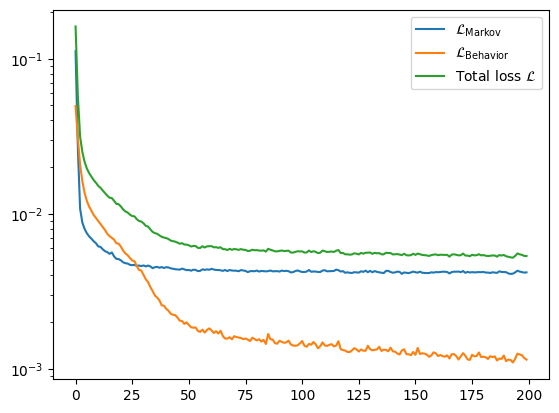

In [4]:
plt.figure()
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

In [5]:
y0_ = model_inference(x_, model)

## Visualising embedding

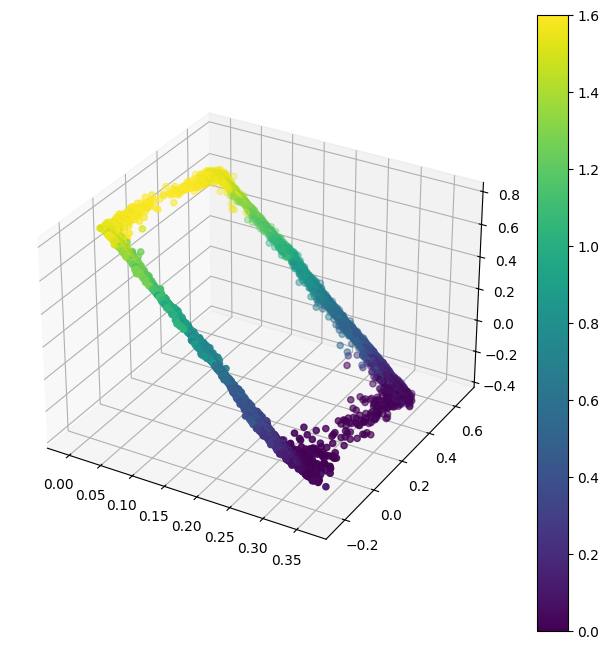

In [6]:
%matplotlib inline
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
true_y_line = ax.scatter(y0_[:, 0], y0_[:, 1], y0_[:, 2], c=b_[:,0])
plt.colorbar(true_y_line)
plt.show()

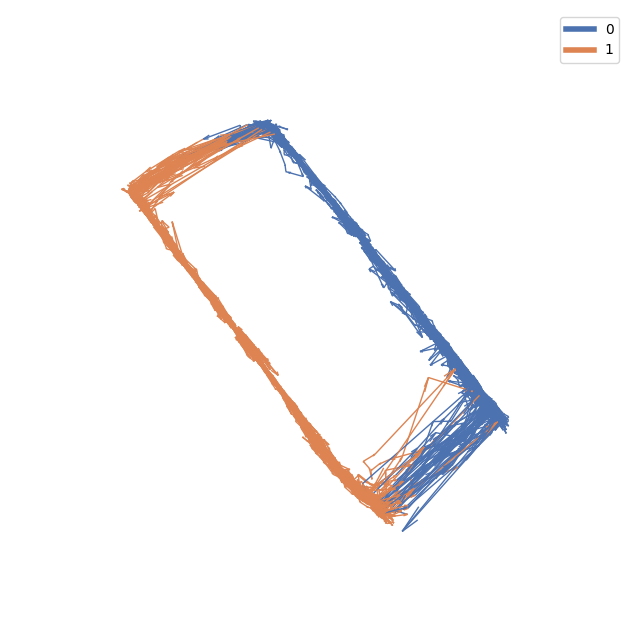

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [7]:
vis = LatentSpaceVisualiser(y0_, b_[:, 1].astype(int), b_names=['0', '1'])
vis.plot_phase_space(filename=f'../figures/phase_space_dynamics_{algorithm}_rat_{rat_name}.png')